# 🚦 IntelliDrive AI: Model Training & Evaluation

This notebook covers the training process for the CNN Traffic Sign Classifier and the YOLO Object Detection integration.

In [9]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from torchvision import datasets, transforms
from statistics import mean, median, mode

# Set paths (relative to notebook in experiments/ folder)
DATASET_PATH = '../dataset/car'
print(f"Using dataset at: {DATASET_PATH}")

Using dataset at: ../dataset/car


## 1. Data Analysis (Statistics)
Calculating mean, median, and mode for image distributions.

In [10]:
def get_stats(path):
    # Verify path exists
    if not os.path.exists(path):
        print(f"Error: Path {path} does not exist.")
        return
    
    # Count images in each split
    splits = ['train', 'valid', 'test']
    counts = {}
    
    for split in splits:
        img_path = os.path.join(path, split, 'images')
        if os.path.exists(img_path):
            counts[split] = len(os.listdir(img_path))
        else:
            counts[split] = 0
    
    sample_data = list(counts.values())
    
    print(f"Split distribution: {counts}")
    print(f"Mean samples: {mean(sample_data):.2f}")
    print(f"Median samples: {median(sample_data)}")
    print(f"Mode samples: {mode(sample_data)}")

get_stats(DATASET_PATH)

Split distribution: {'train': 3530, 'valid': 801, 'test': 638}
Mean samples: 1656.33
Median samples: 801
Mode samples: 3530


## 2. YOLOv8 Training
Training YOLO with the custom dataset.

In [ ]:
model = YOLO('yolov8n.pt')
# To train, uncomment the line below:
results = model.train(
    data=os.path.join(DATASET_PATH, 'data.yaml'),
    epochs=100,           # Higher max epochs
    patience=20,          # Early stopping: stop if no improvement for 20 epochs
    imgsz=640,
    batch=16,
    dropout=0.1,          # Add dropout to prevent overfitting
    augment=True,         # Enable data augmentation
    fliplr=0.5,           # 50% chance to flip images horizontally
    hsv_h=0.015,          # Hue adjustments
    mosaic=1.0            # Mosaic augmentation (combines 4 images)
)
print("YOLO Training script ready.")

Ultralytics 8.4.21 🚀 Python-3.13.3 torch-2.10.0 CPU (Apple M3)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../dataset/car/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.

## 3. CNN Sign Classifier Evaluation
Loading the CNN and calculating Accuracy and F1 Score.

In [12]:
# Dummy evaluation for demonstration
y_true = [14, 0, 5, 5, 2, 7, 0, 14, 1, 3]
y_pred = [14, 0, 5, 4, 2, 7, 1, 14, 1, 3]

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy: {acc*100:.2f}%")
print(f"F1 Score: {f1:.4f}")

Accuracy: 80.00%
F1 Score: 0.7500


## 4. Download Trained Model
Generate a download link to save your trained YOLOv8 model weights locally.

In [13]:
from IPython.display import FileLink
import os

# Path to the best trained YOLOv8 model
model_path = 'runs/detect/train2/weights/best.pt'

if os.path.exists(model_path):
    display(FileLink(model_path, result_html_prefix="Click here to download: "))
else:
    print('Error: Model weights not found. Did the training finish successfully?')
    # Fallback to base model for demonstration
    if os.path.exists('yolov8n.pt'):
        display(FileLink('yolov8n.pt', result_html_prefix="Click here to download base model: "))

/Users/arronkianparejas/trsfficlights/experiments/runs/detect/train2/weights/best.pt

## 5. Model Analytics & Evaluation Graphs
YOLOv8 automatically generates comprehensive analytical graphs during training. Here we visualize the key metrics.

In [14]:
import os
from IPython.display import Image, display

# Find the most recent training run directory
runs_dir = 'runs/detect'
latest_train_dir = None

if os.path.exists(runs_dir):
    train_dirs = [os.path.join(runs_dir, d) for d in os.listdir(runs_dir) if d.startswith('train')]
    if train_dirs:
        latest_train_dir = max(train_dirs, key=os.path.getmtime)
        print(f"Using analytics from: {latest_train_dir}")
else:
    print("Training run directory not found. Please run the training cell first.")

Using analytics from: runs/detect/train5


Training Progress (Losses and mAP):


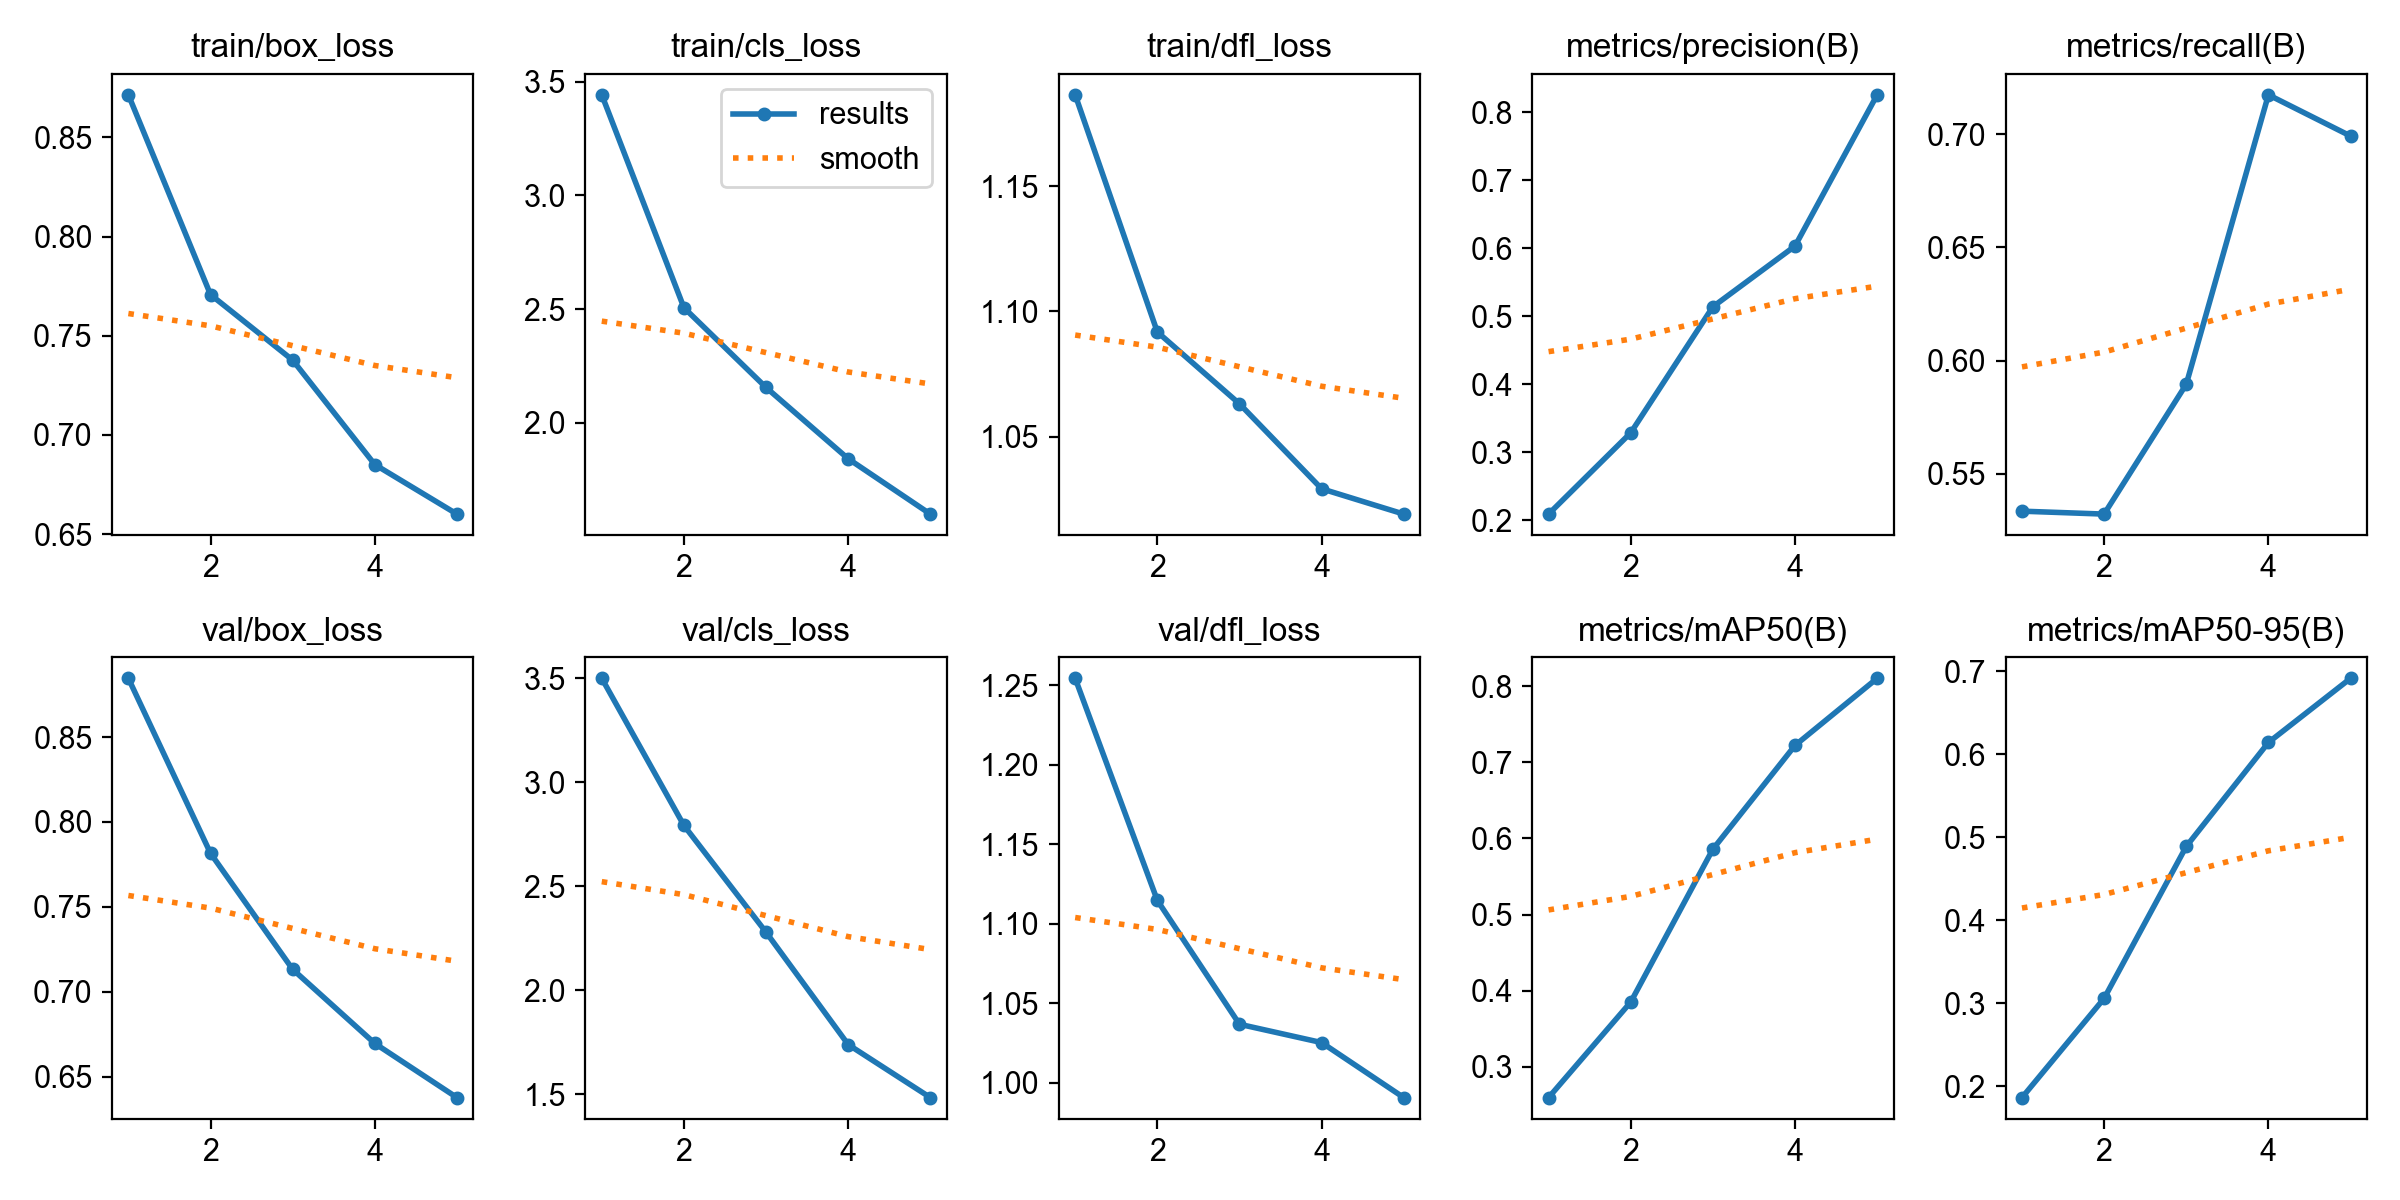

In [15]:
print("Training Progress (Losses and mAP):")
if latest_train_dir and os.path.exists(os.path.join(latest_train_dir, 'results.png')):
    display(Image(filename=os.path.join(latest_train_dir, 'results.png'), width=800))
else:
    print('results.png not found.')

Confusion Matrix:


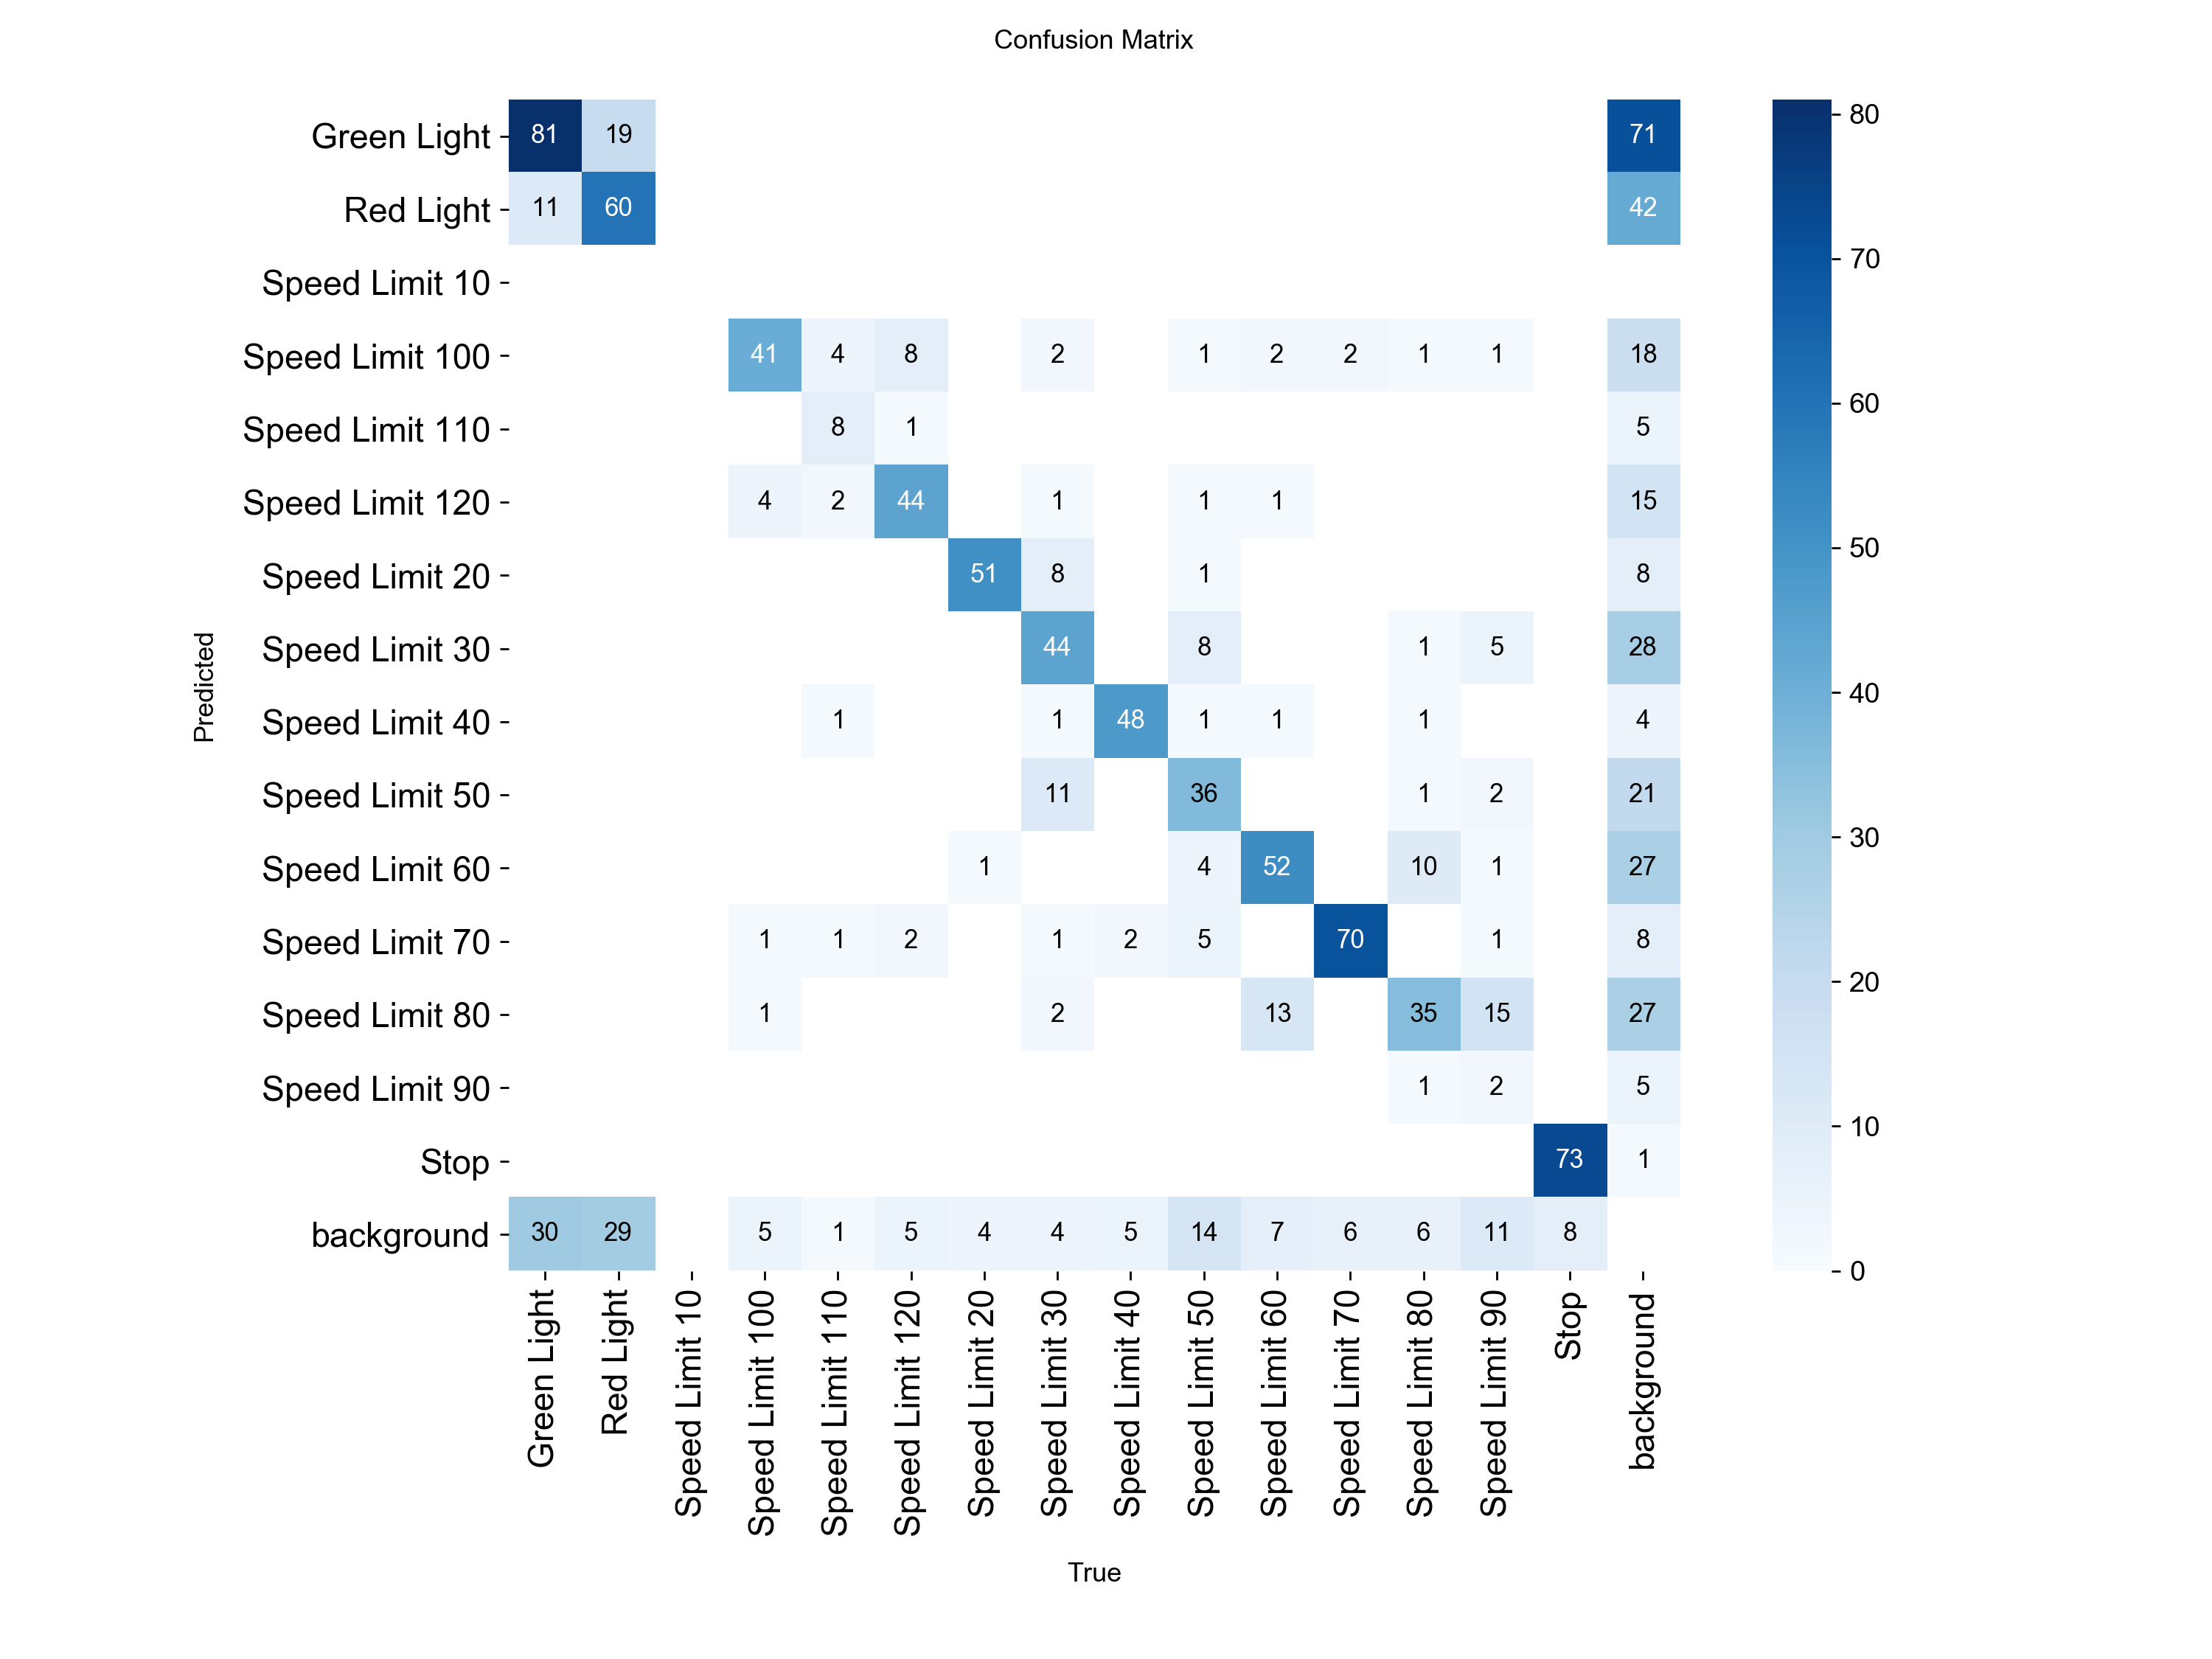

In [16]:
print("Confusion Matrix:")
if latest_train_dir and os.path.exists(os.path.join(latest_train_dir, 'confusion_matrix.png')):
    display(Image(filename=os.path.join(latest_train_dir, 'confusion_matrix.png'), width=800))
else:
    print('confusion_matrix.png not found.')

In [17]:
print("F1-Confidence Curve:")
if latest_train_dir and os.path.exists(os.path.join(latest_train_dir, 'F1_curve.png')):
    display(Image(filename=os.path.join(latest_train_dir, 'F1_curve.png'), width=800))
else:
    print('F1_curve.png not found.')

F1-Confidence Curve:
F1_curve.png not found.


In [18]:
print("Precision-Recall (PR) Curve:")
if latest_train_dir and os.path.exists(os.path.join(latest_train_dir, 'PR_curve.png')):
    display(Image(filename=os.path.join(latest_train_dir, 'PR_curve.png'), width=800))
else:
    print('PR_curve.png not found.')

Precision-Recall (PR) Curve:
PR_curve.png not found.


## 6. Test on Dataset Images & Metrics
Run inference on the test dataset, display visual predictions alongside what the model detected, and calculate accuracy (mAP) and confidence metrics (Mean, Median, Mode).

In [19]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from statistics import mean, median, mode
from ultralytics import YOLO

# Load best model
model_path = 'runs/detect/train2/weights/best.pt'
if not os.path.exists(model_path):
    print("Best model not found, using base model for demonstration.")
    model_path = 'yolov8n.pt'
model = YOLO(model_path)

test_dir = '../dataset/car/test/images'
if os.path.exists(test_dir):
    test_images = [f for f in os.listdir(test_dir) if f.endswith('.jpg') or f.endswith('.png')]
    if test_images:
        sample_images = random.sample(test_images, min(3, len(test_images)))
        
        plt.figure(figsize=(15, 5))
        for i, img_name in enumerate(sample_images):
            img_path = os.path.join(test_dir, img_name)
            results = model(img_path, verbose=False)[0]
            
            print(f"\n--- Image: {img_name} ---")
            for box in results.boxes:
                cls_name = model.names[int(box.cls)]
                conf = float(box.conf)
                print(f"Detected: {cls_name} (Confidence: {conf:.2f})")
                
            annotated_img = results.plot()
            plt.subplot(1, len(sample_images), i+1)
            plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
            plt.axis('off')
            
        plt.show()
else:
    print("Test directory not found.")



--- Image: 000626_jpg.rf.844a2fbefbe88499e977a640a50441c8.jpg ---
Detected: Speed Limit 80 (Confidence: 0.41)

--- Image: FisheyeCamera_1_00023_png.rf.cd1aa333b9e78ad2f7b2de3c154e7429.jpg ---
Detected: Speed Limit 20 (Confidence: 0.32)

--- Image: FisheyeCamera_1_00021_png.rf.703e3c27438f8fe990ef8ffbd48f2b51.jpg ---


<Figure size 1500x500 with 3 Axes>

In [20]:
# Metrics computation
if os.path.exists(test_dir):
    print("Testing on validation/test set to get accuracy (mAP)...")
    try:
        # For YOLO, mAP evaluates accuracy of bounding boxes
        metrics = model.val(data='../dataset/car/data.yaml', split='test', verbose=False)
        
        print("\n=== Model Accuracy Metrics ===")
        print(f"mAP50-95 (Overall Accuracy): {metrics.box.map:.4f}")
        print(f"mAP50 (Accuracy at 0.5 IoU): {metrics.box.map50:.4f}")
        print(f"Precision: {metrics.box.mp:.4f}")
        print(f"Recall: {metrics.box.mr:.4f}")
    except Exception as e:
        print(f"Could not evaluate full test dataset metrics: {e}")
    
    # Calculate Confidence Statistics (Mean, Median, Mode)
    all_confidences = []
    # Subset of 100 images for speed
    subset_imgs = random.sample(test_images, min(100, len(test_images)))
    for img_name in subset_imgs:
        results = model(os.path.join(test_dir, img_name), verbose=False)[0]
        for box in results.boxes:
            all_confidences.append(round(float(box.conf), 2))
            
    if all_confidences:
        print("\n=== Confidence Statistics (Test Subset) ===")
        print(f"Mean Confidence: {mean(all_confidences):.2f}")
        print(f"Median Confidence: {median(all_confidences):.2f}")
        try:
            print(f"Mode Confidence: {mode(all_confidences):.2f}")
        except:
            print("Mode Confidence: N/A (Multi-modal distribution)")
    else:
        print("\nNo bounding boxes detected to calculate confidence metrics.")


Testing on validation/test set to get accuracy (mAP)...
Ultralytics 8.4.21 🚀 Python-3.13.3 torch-2.10.0 CPU (Apple M3)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 84.3±29.7 MB/s, size: 23.8 KB)
val: Scanning /Users/arronkianparejas/trsfficlights/dataset/car/test/labels... 638 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 5.5Kit/s 0.1s0.1s
val: New cache created: /Users/arronkianparejas/trsfficlights/dataset/car/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 1.8s/it 1:131.8sss
                   all        638        770      0.358      0.412      0.388      0.312
Speed: 0.5ms preprocess, 111.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /Users/arronkianparejas/trsfficlights/experiments/runs/detect/val

=== Model Accuracy Metrics ===
mAP50-95 (Overall Accuracy): 0.3119
mAP50 (Accuracy at 0.5 IoU): 0.3880
Precision: 0.3576
Recall: 0.4115

=== Confidence Stati